# Team Members: Govind Pathak : 25020749 | Ralston Dcruz : 25051032  
## CS6482 - Deep Reinforcement Learning
## Assignment 1: Convolutional Neural Networks - Bone Fracture Detection using Faster R-CNN

**Submission Date:** 18th March 2026  
**Dataset:** [Bone Fracture Detection - pkdarabi (Kaggle)](https://www.kaggle.com/datasets/pkdarabi/bone-fracture-detection-computer-vision-project)  
**Architecture:** Faster R-CNN with ResNet-50 FPN backbone (PyTorch / TorchVision)  
**Source reference:** TorchVision Detection Tutorial - https://docs.pytorch.org/tutorials/intermediate/torchvision_tutorial.html*


## Section 1 - The Dataset (Ref: 2 - Report)
### 1.1 - Download
The dataset is the **Bone Fracture Detection** dataset by `pkdarabi` on Kaggle (CC BY 4.0). It contains X-ray images with polygon bounding annotations in YOLOv8 format: 3,631 training, 348 validation, and 169 test images at 512×420 resolution.


In [ ]:
# Downloads the bone fracture dataset using the Kaggle CLI
!kaggle datasets download -d pkdarabi/bone-fracture-detection-computer-vision-project

Dataset URL: https://www.kaggle.com/datasets/pkdarabi/bone-fracture-detection-computer-vision-project
License(s): Attribution 4.0 International (CC BY 4.0)
bone-fracture-detection-computer-vision-project.zip: Skipping, found more recently modified local copy (use --force to force download)


### 1.2 - Label Format Inspection
Each label file follows the YOLOv8 polygon format: `class x1 y1 x2 y2 ... xn yn` with all coordinates normalised to `[0, 1]`. We inspect a sample to confirm the schema.


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import random

dataset_path = "/kaggle/working/BoneFractureYolo8"
train_label_dir = dataset_path + "/train/labels"

# Reading and printing one raw label file to verify YOLO polygon annotation schema
sample_label = os.listdir(train_label_dir)[0]
with open(os.path.join(train_label_dir, sample_label)) as f:
    print(f.read())  # Expected Output: class cx cy x1 y1 ... (normalised polygon vertices)

4 0.24648433923721313 0.5746093764901161 0.28538692653894027 0.633046767772644 0.1635322303169198 0.7643348440822804 0.1119782424452381 0.7252610012004923


### 1.3 - Visualisation of Annotated Images 
Five random training images with bounding boxes overlaid. Polygon coordinates are de-normalised back to pixel space before drawing. This confirms annotation quality and helps detect any labelling artefacts before training.


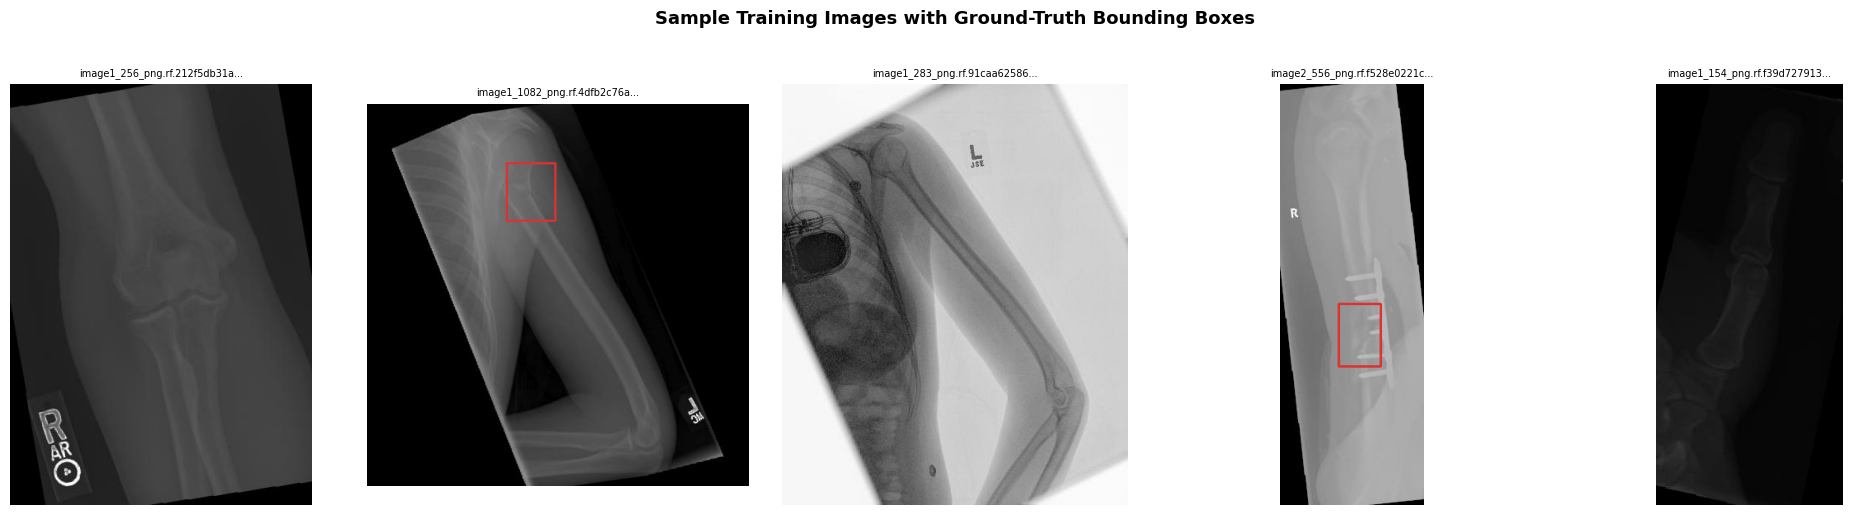

In [ ]:
# Visualise bounding boxes - 5 images in a neat 1×5 grid 
# we pre-load all images into a list and render them together in one figure.
image_dir = "/kaggle/working/BoneFractureYolo8/train/images"
label_dir = "/kaggle/working/BoneFractureYolo8/train/labels"

images_list = os.listdir(image_dir)
sample_images = random.sample(images_list, 5)  # Pick 5 random images

# Pre-collect annotated images so they can be plotted in one figure call
annotated_imgs = []
short_names = []

for img_name in sample_images:
    img_path = os.path.join(image_dir, img_name)
    label_path = os.path.join(label_dir, img_name.replace(".jpg", ".txt"))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR->RGB for matplotlib
    h, w, _ = img.shape

    if os.path.exists(label_path):
        with open(label_path) as f:
            lines = f.readlines()
        for line in lines:
            values = list(map(float, line.split()))
            coords = values[1:]
            xs = [x * w for x in coords[0::2]]  # De-normalise x to pixels
            ys = [y * h for y in coords[1::2]]  # De-normalise y to pixels
            xmin, xmax = int(min(xs)), int(max(xs))
            ymin, ymax = int(min(ys)), int(max(ys))
            cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (220, 50, 50), 2)

    annotated_imgs.append(img)
    # Shorten filename for display 
    short_names.append(img_name[:28] + "...")

# Render all 5 images in a single row
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle("Sample Training Images with Ground-Truth Bounding Boxes",
             fontsize=13, fontweight='bold', y=1.02)

for ax, img, name in zip(axes, annotated_imgs, short_names):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(name, fontsize=7)

plt.tight_layout()
plt.savefig("sample_annotations.png", dpi=120, bbox_inches='tight')
plt.show()


### 1.4 - Dataset Split Counts & Image Shape  
Confirms all three splits are intact and reveals the raw image dimensions used as network input.


In [ ]:
# Define all split directory paths
train_img_dir = "/kaggle/working/BoneFractureYolo8/train/images"
val_img_dir = "/kaggle/working/BoneFractureYolo8/valid/images"
test_img_dir = "/kaggle/working/BoneFractureYolo8/test/images"
train_label_dir = "/kaggle/working/BoneFractureYolo8/train/labels"
val_label_dir = "/kaggle/working/BoneFractureYolo8/valid/labels"
test_label_dir = "/kaggle/working/BoneFractureYolo8/test/labels"

# Count of images and label files per split
print(f"Train  - images: {len(os.listdir(train_img_dir)):>4}  labels: {len(os.listdir(train_label_dir)):>4}")
print(f"Valid  - images: {len(os.listdir(val_img_dir)):>4}  labels: {len(os.listdir(val_label_dir)):>4}")
print(f"Test   - images: {len(os.listdir(test_img_dir)):>4}  labels: {len(os.listdir(test_label_dir)):>4}")

# Count of total fracture annotations in training set and compute average per image
total_objects = sum(len(open(os.path.join(train_label_dir,f)).readlines())
                    for f in os.listdir(train_label_dir))
num_images = len(os.listdir(train_img_dir))
print(f"\nTotal fracture annotations (train): {total_objects}")
print(f"Average fractures per image:         {total_objects/num_images:.4f}")

# Checking raw pixel resolution of one sample image
sample = os.listdir(train_img_dir)[0]
img_chk = cv2.imread(os.path.join(train_img_dir, sample))
print(f"Image shape (H×W×C):                 {img_chk.shape}")

Train  — images: 3631  labels: 3631
Valid  — images:  348  labels:  348
Test   — images:  169  labels:  169

Total fracture annotations (train): 2088
Average fractures per image:         0.5750
Image shape (H×W×C):                 (512, 202, 3)


### 1.5 - Class Distribution & Bounding Box Analysis  
We examine annotation frequency per class and the distribution of bounding box areas (normalised to image size). A right-skewed area distribution would confirm that fracture regions are typically small, motivating the multi-scale FPN backbone choice.


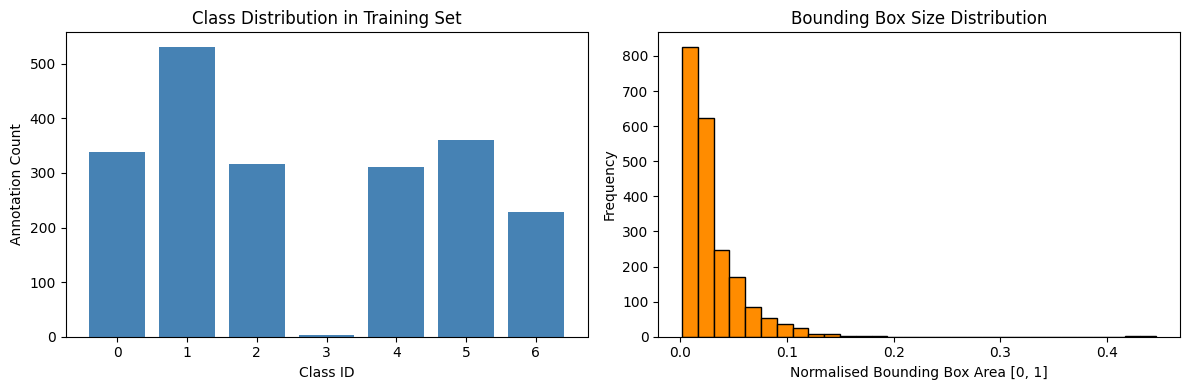

In [ ]:
# Compute per-class annotation counts and normalised bounding box areas
bbox_areas = []   # Normalised area of each ground-truth box (0–1 range)
class_counts = {}   # Maps class_id -> total annotation count

for label_file in os.listdir(train_label_dir):
    with open(os.path.join(train_label_dir, label_file)) as f:
        lines = f.readlines()
    for line in lines:
        values = list(map(float, line.split()))
        cls    = int(values[0])
        coords = values[1:]
        xs = coords[0::2];  ys = coords[1::2]
        area = (max(xs)-min(xs)) * (max(ys)-min(ys))  # Normalised bbox area
        bbox_areas.append(area)
        class_counts[cls] = class_counts.get(cls, 0) + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: class distribution bar chart
axes[0].bar(class_counts.keys(), class_counts.values(), color='steelblue')
axes[0].set_xlabel("Class ID")
axes[0].set_ylabel("Annotation Count")
axes[0].set_title("Class Distribution in Training Set")

# Right: bounding box area histogram
# Right-skewed -> fractures are predominantly small -> motivates FPN multi-scale features
axes[1].hist(bbox_areas, bins=30, color='darkorange', edgecolor='black')
axes[1].set_xlabel("Normalised Bounding Box Area [0, 1]")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Bounding Box Size Distribution")

plt.tight_layout()
plt.show()

## Section 2 - PyTorch Dataset & DataLoader
### 3.1 - Custom Dataset Class  *(Pre-processing)*
The `BoneFractureDataset` class:
1. Reads YOLOv8 polygon labels and converts them to axis-aligned bounding boxes.
2. **Pre-processing:** normalises pixel values from `[0, 255]` -> `[0.0, 1.0]` (division by 255).
3. Returns images as `(C, H, W)` float tensors and targets as dicts required by TorchVision Faster R-CNN.


In [ ]:
import os, torch, numpy as np
from PIL import Image
from torch.utils.data import Dataset

class BoneFractureDataset(Dataset):
    """PyTorch Dataset wrapping the YOLOv8 bone fracture annotation format."""

    def __init__(self, img_dir, label_dir):
        self.img_dir = img_dir
        self.label_dir = label_dir
        # Only include images that have at least one annotated fracture
        self.images = [
            img for img in sorted(os.listdir(img_dir))
            if os.path.exists(os.path.join(label_dir, img.replace(".jpg",".txt")))
            and len(open(os.path.join(label_dir, img.replace(".jpg",".txt"))).readlines()) > 0
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir,   img_name)
        label_path = os.path.join(self.label_dir, img_name.replace(".jpg",".txt"))

        img = Image.open(img_path).convert("RGB")
        w, h = img.size

        boxes, labels = [], []
        if os.path.exists(label_path):
            for line in open(label_path).readlines():
                values = list(map(float, line.split()))
                coords = values[1:]
                xs = [x*w for x in coords[0::2]]
                ys = [y*h for y in coords[1::2]]
                boxes.append([min(xs), min(ys), max(xs), max(ys)])
                labels.append(1)  # 1=fracture; 0 reserved for background

        # Pre-processing: normalise to [0,1] and reorder to (C,H,W)
        img_tensor = torch.tensor(np.array(img)/255.0).permute(2,0,1).float()

        target = {
            "boxes":    torch.as_tensor(boxes,  dtype=torch.float32),
            "labels":   torch.as_tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([idx])
        }
        return img_tensor, target

### 2.2 - Instantiate Datasets & DataLoaders
A custom `collate_fn` is essential because each image may have a different number of bounding boxes - standard tensor stacking would fail. Instead, images and targets are returned as lists, which is the format expected by TorchVision's detection API.


In [ ]:
from torch.utils.data import DataLoader

# Instantiate datasets for both splits
train_dataset = BoneFractureDataset(train_img_dir, train_label_dir)
val_dataset = BoneFractureDataset(val_img_dir,   val_label_dir)
print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# collate_fn: returns tuple-of-lists instead of stacked tensors
# Required because detection targets have variable box counts per image
def collate_fn(batch):
    return tuple(zip(*batch))

# Shuffle training data each epoch, keep validation deterministic
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,  collate_fn=collate_fn)
val_loader = DataLoader(val_dataset,   batch_size=2, shuffle=False, collate_fn=collate_fn)

# checking one batch
images, targets = next(iter(train_loader))
print(f"Batch size: {len(images)}")
print(f"Boxes shape: {targets[0]['boxes'].shape}  - each row: [xmin, ymin, xmax, ymax]")
print(f"Labels:      {targets[0]['labels']}")

Training samples:   1804
Validation samples: 173
Batch size: 2
Boxes shape: torch.Size([1, 4])  — each row: [xmin, ymin, xmax, ymax]
Labels:      tensor([1])


## Section 3 - Network Architecture: Faster R-CNN  (Ref: 3 - Report)
We use **Faster R-CNN with a ResNet-50 + FPN backbone** pre-trained on MS COCO (TorchVision). Transfer learning is applied by replacing only the **Box Predictor** head with a new `FastRCNNPredictor` for `num_classes=2` (background + fracture). All backbone weights are fine-tuned end-to-end.

**Why Faster R-CNN?** The dedicated Region Proposal Network (RPN) generates candidate bounding boxes before classification, making it significantly more accurate on small, localised objects like fracture regions compared to single-stage detectors.

**Loss Function  :** Faster R-CNN optimises a **multi-task loss** composed of:
- `loss_rpn_box_reg` - RPN bounding box regression (smooth L1 loss)
- `loss_objectness` - RPN binary classification (fracture vs background)
- `loss_classifier` - RoI classification cross-entropy
- `loss_box_reg` - RoI bounding box regression (smooth L1 loss)

The total loss is the unweighted sum of all four components.


In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch

# Device selection, GPU if available else CPU will be used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load Faster R-CNN pre-trained on MS COCO (transfer learning) 
# weights='DEFAULT' fetches the latest recommended COCO pre-trained weights
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

num_classes = 2  # Class 0 = background (implicit), Class 1 = fracture

# Reading of the input feature dimension of the existing predictor head
in_features = model.roi_heads.box_predictor.cls_score.in_features

# Replacing the COCO 91-class head with a new 2-class head for fracture detection
# FastRCNNPredictor: two FC layers -> class scores + box regression deltas
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
model.to(device)
print("Model ready - head replaced for", num_classes, "classes")

Using device: cuda
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 229MB/s] 


Model ready — head replaced for 2 classes


## Section 4 - Evaluation Metrics  
For object detection, standard image-classification metrics (accuracy alone) are insufficient. We implement **IoU-based Precision, Recall, and F1** at a threshold of IoU >= 0.5:

- **True Positive (TP):** predicted box matches a ground-truth box with IoU ≥ 0.5 and correct class.
- **False Positive (FP):** predicted box has no matching ground-truth box.
- **False Negative (FN):** ground-truth box has no matching predicted box.
- **Precision** = TP / (TP + FP) - of all detections, how many are correct.
- **Recall** = TP / (TP + FN) - of all ground-truths, how many were found.
- **F1** = 2 × Precision × Recall / (Precision + Recall) - harmonic mean.

A **confusion matrix** is also computed at image level: images classified as correctly detected (TP), missed (FN), or falsely alarmed (FP).


In [ ]:
import numpy as np

def compute_iou(box_a, box_b):
    """Compute Intersection-over-Union between two [xmin,ymin,xmax,ymax] boxes."""
    xa = max(box_a[0], box_b[0]);  ya = max(box_a[1], box_b[1])
    xb = min(box_a[2], box_b[2]);  yb = min(box_a[3], box_b[3])
    inter = max(0, xb-xa) * max(0, yb-ya) # Intersection area
    area_a = (box_a[2]-box_a[0]) * (box_a[3]-box_a[1])
    area_b = (box_b[2]-box_b[0]) * (box_b[3]-box_b[1])
    union = area_a + area_b - inter # Union area
    return inter / union if union > 0 else 0.0


def evaluate_predictions(predictions, targets, iou_threshold=0.5, score_threshold=0.5):
    """
    Compute TP, FP, FN across a batch of predictions.
    Returns total TP, FP, FN counts for the batch.
    """
    total_tp = total_fp = total_fn = 0

    for pred, tgt in zip(predictions, targets):
        pred_boxes = pred["boxes"].cpu().numpy()
        pred_scores = pred["scores"].cpu().numpy()
        gt_boxes = tgt["boxes"].cpu().numpy()

        # Filtering of predictions below confidence threshold
        keep = pred_scores >= score_threshold
        pred_boxes = pred_boxes[keep]

        matched_gt = set()  # Tracks which GT boxes have been matched

        for pb in pred_boxes:
            best_iou = 0.0
            best_gt = -1
            for j, gb in enumerate(gt_boxes):
                if j in matched_gt:
                    continue  # Each GT can only match one prediction
                iou = compute_iou(pb, gb)
                if iou > best_iou:
                    best_iou = iou
                    best_gt = j
            if best_iou >= iou_threshold:
                total_tp += 1
                matched_gt.add(best_gt)
            else:
                total_fp += 1  # No matching GT -> false detection

        # GT boxes with no matching prediction -> false negatives
        total_fn += len(gt_boxes) - len(matched_gt)

    return total_tp, total_fp, total_fn


def compute_metrics(tp, fp, fn):
    """Compute Precision, Recall, and F1 from TP/FP/FN counts."""
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)
    return precision, recall, f1

print("Metric helper functions defined: compute_iou, evaluate_predictions, compute_metrics")

Metric helper functions defined: compute_iou, evaluate_predictions, compute_metrics


### 4.1 - Mean Average Precision (mAP)
**mAP** is the standard metric for object detection benchmarks (PASCAL VOC, MS COCO).

For each class, AP is computed as the **area under the Precision-Recall curve** by:
1. Sorting all predictions by confidence score (descending).
2. Greedily matching each prediction to a ground-truth box at IoU ≥ 0.5.
3. Computing cumulative Precision and Recall at each decision threshold.
4. Integrating: `AP = Σ (R_{n} − R_{n-1}) × P_{n}` (11-point interpolation).

**mAP@0.5** = mean AP over all classes at IoU threshold 0.5.  
Since this dataset has one foreground class (fracture), `mAP@0.5 = AP_fracture`.


In [ ]:
def compute_ap(predictions_all, targets_all, iou_threshold=0.5, score_threshold=0.0):
    """
    Compute Average Precision (AP) for a single class.

    predictions_all : list of dicts {boxes, scores, labels} (one per image)
    targets_all     : list of dicts {boxes, labels}          (one per image)
    Returns: AP value (float), recall_curve, precision_curve
    """
    # Step 1: Collect all (score, is_tp) pairs across the entire dataset
    all_scores = []
    all_tp = []
    n_gt_total = 0  # Total ground-truth boxes across all images

    for pred, tgt in zip(predictions_all, targets_all):
        pred_boxes = pred["boxes"].cpu().numpy()
        pred_scores = pred["scores"].cpu().numpy()
        gt_boxes = tgt["boxes"].cpu().numpy()

        n_gt_total += len(gt_boxes)  # Count all ground-truth boxes

        # Filter by score threshold
        keep = pred_scores >= score_threshold
        pred_boxes  = pred_boxes[keep]
        pred_scores = pred_scores[keep]

        matched_gt = set()
        for pb, sc in zip(pred_boxes, pred_scores):
            best_iou = 0.0;  best_gt = -1
            for j, gb in enumerate(gt_boxes):
                if j in matched_gt:
                    continue
                iou = compute_iou(pb, gb)  # Reuse IoU helper from above
                if iou > best_iou:
                    best_iou = iou;  best_gt = j
            if best_iou >= iou_threshold:
                all_tp.append(1)       # True positive
                matched_gt.add(best_gt)
            else:
                all_tp.append(0)       # False positive
            all_scores.append(sc)

    if len(all_scores) == 0 or n_gt_total == 0:
        return 0.0, [], []

    # Step 2: Sort by descending confidence score
    order = np.argsort(-np.array(all_scores))
    all_tp_s = np.array(all_tp)[order]

    # Step 3: Compute cumulative TP and FP, then derive precision & recall at each threshold
    cum_tp = np.cumsum(all_tp_s)
    cum_fp = np.cumsum(1 - all_tp_s)
    recall_curve = cum_tp / n_gt_total           # Recall = TP / (TP + FN) = TP / n_gt
    precision_curve = cum_tp / (cum_tp + cum_fp)    # Precision = TP / (TP + FP)

    # Step 4: 11-point interpolated AP (VOC style)
    ap = 0.0
    for thr in np.linspace(0, 1, 11):              # 11 recall thresholds: 0.0, 0.1, ..., 1.0
        # Maximum precision at all recall values >= thr
        prec_at_thr = precision_curve[recall_curve >= thr]
        ap += (np.max(prec_at_thr) if len(prec_at_thr) > 0 else 0.0)
    ap /= 11  # Average over 11 recall thresholds

    return ap, recall_curve.tolist(), precision_curve.tolist()


def compute_map_for_fold(fold_model, data_loader, device, iou_threshold=0.5):
    """
    Run inference over an entire DataLoader, collect all predictions and targets,
    then compute mAP@0.5 for the fold.
    """
    fold_model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for imgs, tgts in data_loader:
            imgs = [i.to(device) for i in imgs]
            preds = fold_model(imgs)  # Returns list of {boxes, labels, scores}
            all_preds.extend(preds)
            all_targets.extend(tgts)

    # For a single-class problem, mAP@0.5 = AP of the fracture class
    ap, rec_curve, prec_curve = compute_ap(
        all_preds, all_targets, iou_threshold=iou_threshold
    )
    return ap, rec_curve, prec_curve


print("mAP helpers defined: compute_ap(), compute_map_for_fold()")


mAP helpers defined: compute_ap(), compute_map_for_fold()


## Section 5 - Cross-Fold Validation (3-Fold)  (Ref: 6. - Report)
We apply **3-fold cross-validation** over the training set. For each fold:
1. A fresh Faster R-CNN is initialised from COCO pre-trained weights.
2. Fine-tuned for 5 epochs; per-epoch loss is recorded.
3. Evaluated on the held-out fold to compute **Precision, Recall, F1**.

After all folds, we plot per-fold loss curves and a Precision/Recall/F1 comparison.

**Optimiser :** SGD — `lr=0.005`, `momentum=0.9`, `weight_decay=5e-4`  
**LR Scheduler:** StepLR — multiply LR by 0.1 every 3 epochs to stabilise late training.


In [ ]:
from sklearn.model_selection import KFold
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision, torch
from torch.utils.data import DataLoader

kf = KFold(n_splits=3, shuffle=True, random_state=42)
indices = list(range(len(train_dataset)))

NUM_EPOCHS = 5

# Storage for cross-fold results 
fold_loss_curves = []   # List of lists: fold_loss_curves[fold] = [loss_e1, loss_e2, ...]
fold_precisions = []   # Per-fold validation precision
fold_recalls = []   # Per-fold validation recall
fold_f1s = []   # Per-fold validation F1
fold_tp_fp_fn = []   # Per-fold raw TP, FP, FN counts
fold_maps = []   # Per-fold mAP@0.5 (area under PR curve, 11-point interpolation)
fold_pr_curves = []   # Per-fold (recall_list, precision_list) for PR curve plotting
loss_history = []   # Flat epoch loss across all folds (for single-line loss curve)

for fold, (train_idx, val_idx) in enumerate(kf.split(indices)):
    print(f"\n{'='*50}\nFold {fold+1} / 3\n{'='*50}")

    # Build per-fold Subset DataLoaders
    train_sub = torch.utils.data.Subset(train_dataset, train_idx)
    val_sub = torch.utils.data.Subset(train_dataset, val_idx)
    fold_train = DataLoader(train_sub, batch_size=2, shuffle=True,  collate_fn=collate_fn)
    fold_val = DataLoader(val_sub,   batch_size=2, shuffle=False, collate_fn=collate_fn)

    # Fresh model for every fold - prevents information leakage between folds
    fold_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    in_feat = fold_model.roi_heads.box_predictor.cls_score.in_features
    fold_model.roi_heads.box_predictor = FastRCNNPredictor(in_feat, num_classes=2)
    fold_model.to(device)

    # Optimiser: SGD with momentum and L2 regularisation
    # SGD chosen following the original Faster R-CNN paper (Ren et al., 2015)
    params = [p for p in fold_model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

    # StepLR: decay LR by factor 10 every 3 epochs to improve late-epoch convergence
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

    epoch_losses = []  # Track average loss per epoch for this fold

    # Training Loop
    for epoch in range(NUM_EPOCHS):
        fold_model.train()  # Enable training mode (BatchNorm in train behaviour)
        epoch_loss = 0.0

        for imgs, tgts in fold_train:
            imgs = [i.to(device) for i in imgs]
            tgts = [{k: v.to(device) for k,v in t.items()} for t in tgts]

            # Forward pass - in train mode returns dict of four loss components
            loss_dict = fold_model(imgs, tgts)
            # Total loss = sum of rpn_box_reg + objectness + classifier + box_reg
            losses = sum(loss_dict.values())

            optimizer.zero_grad()  # Clear accumulated gradients from previous step
            losses.backward()      # Backpropagate: compute loss/weights
            optimizer.step()       # SGD update: w <- w - lr × gradient
            epoch_loss += losses.item()

        scheduler.step()  # Apply LR decay at end of epoch
        avg_loss = epoch_loss / len(fold_train)  # Per-batch average
        epoch_losses.append(avg_loss)
        loss_history.append(avg_loss)
        print(f"  Epoch {epoch+1}/{NUM_EPOCHS}  loss={avg_loss:.4f}  "
              f"lr={scheduler.get_last_lr()[0]:.5f}")

    fold_loss_curves.append(epoch_losses)  # Store full loss curve for this fold

    # Validation: compute Precision, Recall, F1, and mAP@0.5
    fold_model.eval()
    total_tp = total_fp = total_fn = 0
    fold_all_preds = []  # Collect all predictions for this fold's val set
    fold_all_targets = []  # Collect all ground-truth targets

    with torch.no_grad():
        for imgs, tgts in fold_val:
            imgs = [i.to(device) for i in imgs]
            preds = fold_model(imgs)  # Inference: returns boxes, labels, scores per image
            # Accumulate TP/FP/FN for Precision/Recall/F1
            tp, fp, fn = evaluate_predictions(preds, tgts, iou_threshold=0.5,
                                              score_threshold=0.5)
            total_tp += tp;  total_fp += fp;  total_fn += fn
            fold_all_preds.extend(preds)    # Store for mAP curve
            fold_all_targets.extend(tgts)   # Store for mAP curve

    p, r, f1 = compute_metrics(total_tp, total_fp, total_fn)
    fold_precisions.append(p)
    fold_recalls.append(r)
    fold_f1s.append(f1)
    fold_tp_fp_fn.append((total_tp, total_fp, total_fn))

    # Compute AP (and full PR curve) for this fold
    fold_ap, fold_rec_curve, fold_prec_curve = compute_ap(
        fold_all_preds, fold_all_targets, iou_threshold=0.5
    )
    fold_maps.append(fold_ap)              # Store mAP@0.5 for this fold
    fold_pr_curves.append((fold_rec_curve, fold_prec_curve))  # Store PR curve

    print(f"  Fold {fold+1} Validation -> Precision:{p:.4f}  Recall:{r:.4f}  "
          f"F1:{f1:.4f}  mAP@0.5:{fold_ap:.4f}")
    print(f"  TP={total_tp}  FP={total_fp}  FN={total_fn}")

print(f"\n{'='*50}")
print(f"Cross-Validation Summary")
print(f"  Mean Precision : {np.mean(fold_precisions):.4f} ± {np.std(fold_precisions):.4f}")
print(f"  Mean Recall    : {np.mean(fold_recalls):.4f} ± {np.std(fold_recalls):.4f}")
print(f"  Mean F1        : {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")
print(f"  Mean mAP@0.5   : {np.mean(fold_maps):.4f} ± {np.std(fold_maps):.4f}")


Fold 1 / 3
  Epoch 1/5  loss=0.2611  lr=0.00500
  Epoch 2/5  loss=0.2384  lr=0.00500
  Epoch 3/5  loss=0.2027  lr=0.00050
  Epoch 4/5  loss=0.1432  lr=0.00050
  Epoch 5/5  loss=0.1178  lr=0.00050
  Fold 1 Validation → Precision:0.5874  Recall:0.6758  F1:0.6285  mAP@0.5:0.6333
  TP=467  FP=328  FN=224

Fold 2 / 3
  Epoch 1/5  loss=0.2650  lr=0.00500
  Epoch 2/5  loss=0.2393  lr=0.00500
  Epoch 3/5  loss=0.2071  lr=0.00050
  Epoch 4/5  loss=0.1480  lr=0.00050
  Epoch 5/5  loss=0.1208  lr=0.00050
  Fold 2 Validation → Precision:0.6034  Recall:0.6686  F1:0.6343  mAP@0.5:0.6304
  TP=464  FP=305  FN=230

Fold 3 / 3
  Epoch 1/5  loss=0.2562  lr=0.00500
  Epoch 2/5  loss=0.2355  lr=0.00500
  Epoch 3/5  loss=0.2081  lr=0.00050
  Epoch 4/5  loss=0.1518  lr=0.00050
  Epoch 5/5  loss=0.1255  lr=0.00050
  Fold 3 Validation → Precision:0.6404  Recall:0.6358  F1:0.6381  mAP@0.5:0.6244
  TP=447  FP=251  FN=256

Cross-Validation Summary
  Mean Precision : 0.6104 ± 0.0222
  Mean Recall    : 0.6601 ± 0.

## Section 6 - Cross-Fold Training & Validation Results  
Four plots are produced:
1. **Per-fold loss curves** - shows convergence behaviour for each fold separately.
2. **Precision, Recall, F1 per fold** - bar chart comparing metric values per fold.
3. **Mean ± std metrics** - error bars summarising cross-validation stability.
4. **Confusion matrix** - aggregate TP / FP / FN counts across all folds as a heatmap.


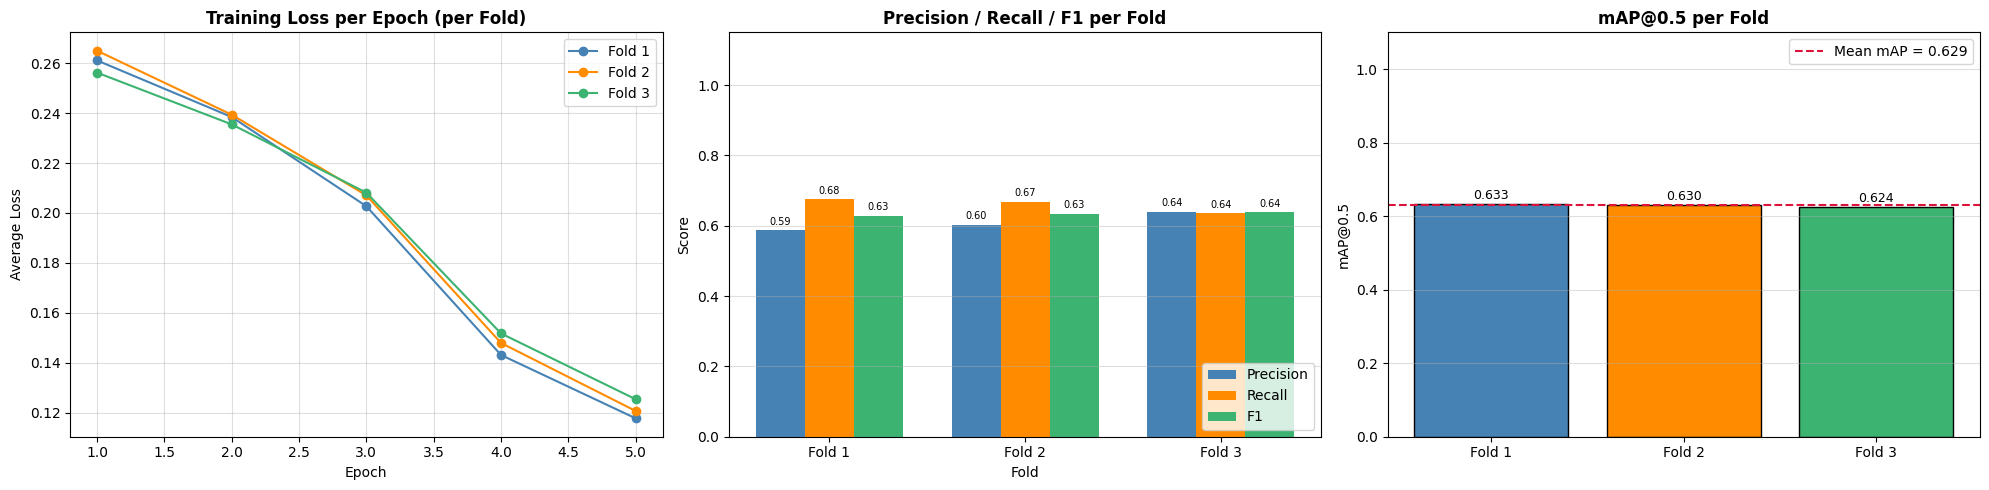

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1: Per-fold training loss curves
colors = ['steelblue', 'darkorange', 'mediumseagreen']
for fold_idx, (losses, col) in enumerate(zip(fold_loss_curves, colors)):
    axes[0].plot(range(1, len(losses)+1), losses, marker='o',
                 color=col, label=f'Fold {fold_idx+1}')
axes[0].set_title('Training Loss per Epoch (per Fold)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Average Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Panel 2: Precision / Recall / F1 grouped bar chart per fold 
x     = np.arange(3)
width = 0.25
axes[1].bar(x - width, fold_precisions, width, label='Precision', color='steelblue')
axes[1].bar(x, fold_recalls, width, label='Recall', color='darkorange')
axes[1].bar(x + width, fold_f1s, width, label='F1', color='mediumseagreen')
for xi, (vals, off) in enumerate(zip(
        [fold_precisions, fold_recalls, fold_f1s], [-width, 0, width])):
    for fi, val in enumerate(vals):
        axes[1].text(fi + off, val + 0.01, f'{val:.2f}',
                     ha='center', va='bottom', fontsize=7)
axes[1].set_title('Precision / Recall / F1 per Fold', fontweight='bold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Score')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Fold {i+1}' for i in range(3)])
axes[1].set_ylim(0, 1.15)
axes[1].legend(loc='lower right')
axes[1].grid(axis='y', alpha=0.4)

# Panel 3: mAP@0.5 per fold bar chart with mean reference line 
map_colors = ['steelblue', 'darkorange', 'mediumseagreen']
bars = axes[2].bar([f'Fold {i+1}' for i in range(3)], fold_maps,
                   color=map_colors, edgecolor='black')
mean_map = np.mean(fold_maps)
axes[2].axhline(mean_map, color='crimson', linestyle='--', linewidth=1.5,
                label=f'Mean mAP = {mean_map:.3f}')
for bar, val in zip(bars, fold_maps):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)
axes[2].set_title('mAP@0.5 per Fold', fontweight='bold')
axes[2].set_ylabel('mAP@0.5')
axes[2].set_ylim(0, 1.1)
axes[2].legend()
axes[2].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('fold_results.png', dpi=120, bbox_inches='tight')
plt.show()


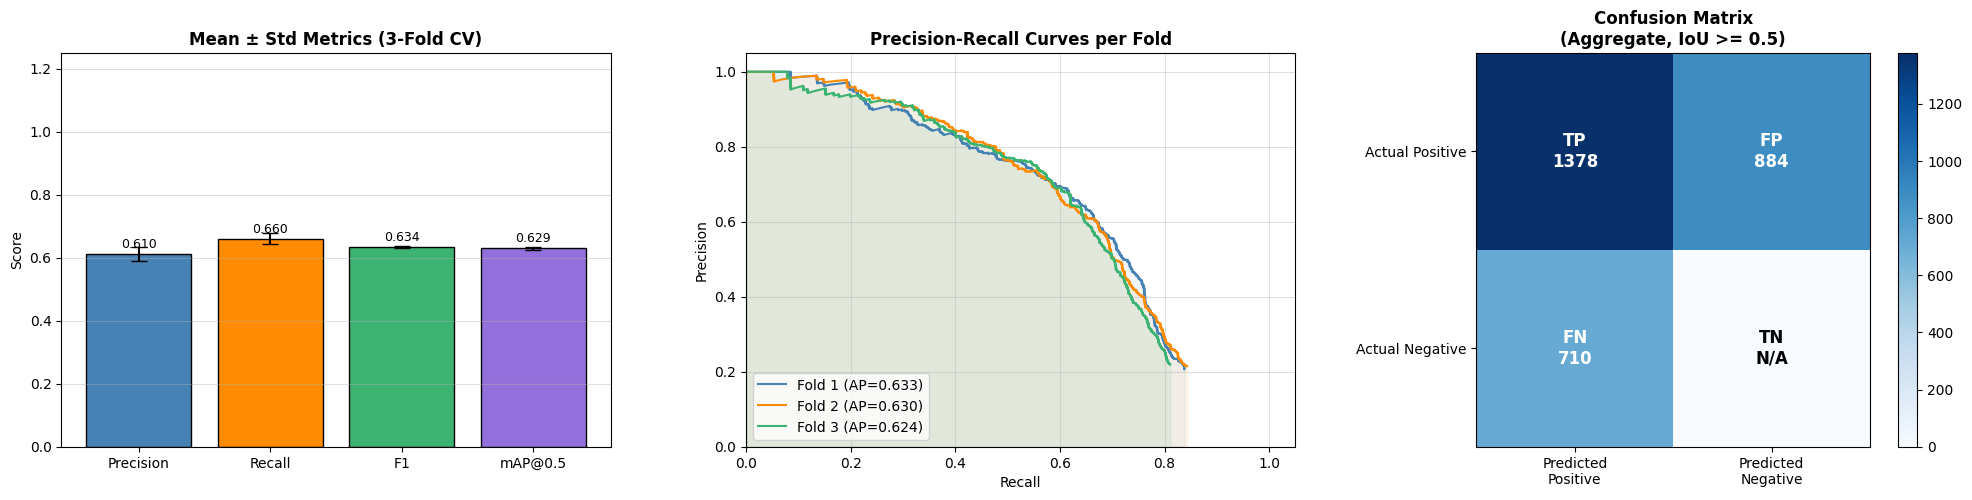

Aggregate  TP=1378  FP=884  FN=710
Mean mAP@0.5 = 0.6294 +/- 0.0037


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1: Mean ± Std metrics bar chart (Precision, Recall, F1, mAP@0.5) 
metric_names = ['Precision', 'Recall', 'F1', 'mAP@0.5']
metric_means = [np.mean(fold_precisions), np.mean(fold_recalls),
                  np.mean(fold_f1s),        np.mean(fold_maps)]
metric_stds = [np.std(fold_precisions),  np.std(fold_recalls),
                  np.std(fold_f1s),         np.std(fold_maps)]
metric_colors = ['steelblue', 'darkorange', 'mediumseagreen', 'mediumpurple']

bars = axes[0].bar(metric_names, metric_means, yerr=metric_stds,
                   color=metric_colors, capsize=6, edgecolor='black')
for bar, val in zip(bars, metric_means):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)
axes[0].set_title('Mean ± Std Metrics (3-Fold CV)', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.25)
axes[0].grid(axis='y', alpha=0.4)

# Panel 2: Precision-Recall curves per fold 
# AUC of this curve = Average Precision (AP). For single-class, AP = mAP.
colors = ['steelblue', 'darkorange', 'mediumseagreen']
for fold_idx, ((rec_c, prec_c), ap_val, col) in enumerate(
        zip(fold_pr_curves, fold_maps, colors)):
    if len(rec_c) > 1:
        sorted_pairs = sorted(zip(rec_c, prec_c))
        rec_s  = [p[0] for p in sorted_pairs]
        prec_s = [p[1] for p in sorted_pairs]
        axes[1].plot(rec_s, prec_s, color=col,
                     label=f'Fold {fold_idx+1} (AP={ap_val:.3f})')
        axes[1].fill_between(rec_s, prec_s, alpha=0.08, color=col)
axes[1].set_title('Precision-Recall Curves per Fold', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_xlim(0, 1.05)
axes[1].set_ylim(0, 1.05)
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.4)

# Panel 3: Confusion matrix heatmap (aggregate TP/FP/FN across all folds) 
agg_tp = sum(r[0] for r in fold_tp_fp_fn)
agg_fp = sum(r[1] for r in fold_tp_fp_fn)
agg_fn = sum(r[2] for r in fold_tp_fp_fn)
conf_matrix = np.array([[agg_tp, agg_fp],
                         [agg_fn, 0]])
im = axes[2].imshow(conf_matrix, cmap='Blues')
plt.colorbar(im, ax=axes[2])
axes[2].set_xticks([0,1])
axes[2].set_xticklabels(['Predicted\nPositive', 'Predicted\nNegative'])
axes[2].set_yticks([0,1])
axes[2].set_yticklabels(['Actual Positive', 'Actual Negative'])
axes[2].set_title('Confusion Matrix\n(Aggregate, IoU >= 0.5)', fontweight='bold')
cell_labels = [[f'TP\n{agg_tp}', f'FP\n{agg_fp}'],
               [f'FN\n{agg_fn}', 'TN\nN/A']]
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, cell_labels[i][j], ha='center', va='center',
                     color='white' if conf_matrix[i,j] > conf_matrix.max()/2 else 'black',
                     fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('metrics_summary.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Aggregate  TP={agg_tp}  FP={agg_fp}  FN={agg_fn}')
print(f'Mean mAP@0.5 = {np.mean(fold_maps):.4f} +/- {np.std(fold_maps):.4f}')


## Section 7 - Experiments (Ref: 9 - Report)
### Experiment 1 - Backbone Architecture Comparison
Two Faster R-CNN variants are compared under identical training conditions:
- **ResNet-50 + FPN** - deeper backbone, richer feature hierarchy, higher parameter count
- **MobileNetV3 Large + FPN** - lightweight backbone, faster inference, fewer parameters

We track the **full per-epoch loss curve** for each backbone (not just the final value) to compare convergence speed as well as final loss.


In [ ]:
# Experiment 1: Backbone Comparison (ResNet-50 FPN vs MobileNetV3 FPN) 

models_to_test = {
    "ResNet50_FPN":    torchvision.models.detection.fasterrcnn_resnet50_fpn,
    "MobileNetV3_FPN": torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn
}

exp1_results = {}  # {model_name: [epoch_loss_1, epoch_loss_2, ...]}
NUM_EPOCHS = 5

for model_name, model_fn in models_to_test.items():
    print(f"\nRunning: {model_name}")

    exp_model = model_fn(pretrained=True)
    in_feat   = exp_model.roi_heads.box_predictor.cls_score.in_features
    exp_model.roi_heads.box_predictor = FastRCNNPredictor(in_feat, 2)
    exp_model.to(device)

    params = [p for p in exp_model.parameters() if p.requires_grad]
    exp_opt = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
    exp_sched = torch.optim.lr_scheduler.StepLR(exp_opt, step_size=3, gamma=0.1)

    epoch_curve = []  # Store per-epoch average loss for line-plot comparison

    for epoch in range(NUM_EPOCHS):
        exp_model.train()
        epoch_loss = 0.0

        for imgs, tgts in train_loader:
            imgs = [i.to(device) for i in imgs]
            tgts = [{k: v.to(device) for k,v in t.items()} for t in tgts]
            loss_dict = exp_model(imgs, tgts)
            losses    = sum(loss_dict.values())
            exp_opt.zero_grad()
            losses.backward()
            exp_opt.step()
            epoch_loss += losses.item()

        exp_sched.step()
        avg = epoch_loss / len(train_loader)
        epoch_curve.append(avg)
        print(f"  Epoch {epoch+1}  avg_loss={avg:.4f}")

    exp1_results[model_name] = epoch_curve

print("\nExperiment 1 complete.")


Running: ResNet50_FPN


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Epoch 1  avg_loss=0.2535
  Epoch 2  avg_loss=0.2273
  Epoch 3  avg_loss=0.1932
  Epoch 4  avg_loss=0.1332
  Epoch 5  avg_loss=0.1065

Running: MobileNetV3_FPN
Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_MobileNet_V3_Large_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 74.2M/74.2M [00:00<00:00, 218MB/s]


  Epoch 1  avg_loss=0.3079
  Epoch 2  avg_loss=0.3049
  Epoch 3  avg_loss=0.3231
  Epoch 4  avg_loss=0.3399
  Epoch 5  avg_loss=0.3310

Experiment 1 complete.


### Experiment 2 - Learning Rate Sensitivity Study
We test `lr ∈ {0.005, 0.01}` on ResNet-50 FPN to understand how the initial learning rate affects convergence speed and final loss. Per-epoch losses are stored for line-plot comparison.


In [ ]:
# Experiment 2: Learning Rate Study (0.005 vs 0.01) 

learning_rates = [0.005, 0.01]
exp2_results = {}  # {lr: [epoch_loss_1, epoch_loss_2, ...]}

for lr in learning_rates:
    print(f"\nRunning: lr={lr}")

    exp_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    in_feat = exp_model.roi_heads.box_predictor.cls_score.in_features
    exp_model.roi_heads.box_predictor = FastRCNNPredictor(in_feat, 2)
    exp_model.to(device)

    params = [p for p in exp_model.parameters() if p.requires_grad]
    exp_opt = torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=0.0005)
    exp_sched = torch.optim.lr_scheduler.StepLR(exp_opt, step_size=3, gamma=0.1)

    epoch_curve = []

    for epoch in range(NUM_EPOCHS):
        exp_model.train()
        epoch_loss = 0.0

        for imgs, tgts in train_loader:
            imgs = [i.to(device) for i in imgs]
            tgts = [{k: v.to(device) for k,v in t.items()} for t in tgts]
            loss_dict = exp_model(imgs, tgts)
            losses = sum(loss_dict.values())
            exp_opt.zero_grad()
            losses.backward()
            exp_opt.step()
            epoch_loss += losses.item()

        exp_sched.step()
        avg = epoch_loss / len(train_loader)
        epoch_curve.append(avg)
        print(f"  Epoch {epoch+1}  avg_loss={avg:.4f}")

    exp2_results[lr] = epoch_curve

print("\nExperiment 2 complete.")


Running: lr=0.005
  Epoch 1  avg_loss=0.2605
  Epoch 2  avg_loss=0.2273
  Epoch 3  avg_loss=0.1891
  Epoch 4  avg_loss=0.1264
  Epoch 5  avg_loss=0.1008

Running: lr=0.01
  Epoch 1  avg_loss=0.2607
  Epoch 2  avg_loss=0.2377
  Epoch 3  avg_loss=0.2062
  Epoch 4  avg_loss=0.1458
  Epoch 5  avg_loss=0.1161

Experiment 2 complete.


## Section 8 - Experiment Results
Per-epoch loss curves give a much richer view of training dynamics than a single final-value bar chart - they reveal convergence speed, effect of LR scheduling, and stability.


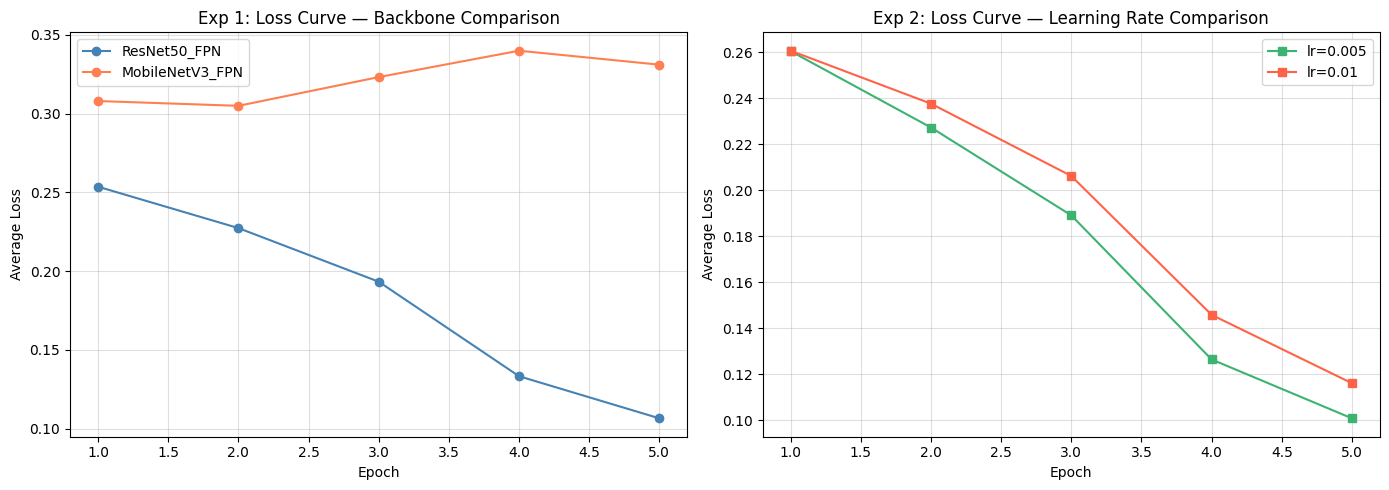

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Experiment 1: Loss curves per backbone 
colors = ['steelblue', 'coral']
for (model_name, curve), col in zip(exp1_results.items(), colors):
    axes[0].plot(range(1, len(curve)+1), curve, marker='o', color=col, label=model_name)
axes[0].set_title("Exp 1: Loss Curve — Backbone Comparison")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Average Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Experiment 2: Loss curves per learning rate 
colors = ['mediumseagreen', 'tomato']
for (lr, curve), col in zip(exp2_results.items(), colors):
    axes[1].plot(range(1, len(curve)+1), curve, marker='s', color=col, label=f"lr={lr}")
axes[1].set_title("Exp 2: Loss Curve — Learning Rate Comparison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Average Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("experiment_loss_curves.png", dpi=120)
plt.show()

In [ ]:
# Final-epoch loss summary table 
import pandas as pd

summary_rows = []
for name, curve in exp1_results.items():
    summary_rows.append({"Experiment":"Backbone", "Config":name,
                         "Final Loss":f"{curve[-1]:.4f}", "Best Loss":f"{min(curve):.4f}"})
for lr, curve in exp2_results.items():
    summary_rows.append({"Experiment":"Learning Rate", "Config":f"lr={lr}",
                         "Final Loss":f"{curve[-1]:.4f}", "Best Loss":f"{min(curve):.4f}"})

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

   Experiment          Config Final Loss Best Loss
     Backbone    ResNet50_FPN     0.1065    0.1065
     Backbone MobileNetV3_FPN     0.3310    0.3049
Learning Rate        lr=0.005     0.1008    0.1008
Learning Rate         lr=0.01     0.1161    0.1161


## Section 9 - Inference & Prediction Visualisation
We run the final trained model (last fold's model) in evaluation mode on a validation batch and visualise predictions at two confidence thresholds: **unfiltered** and **score > 0.5**.


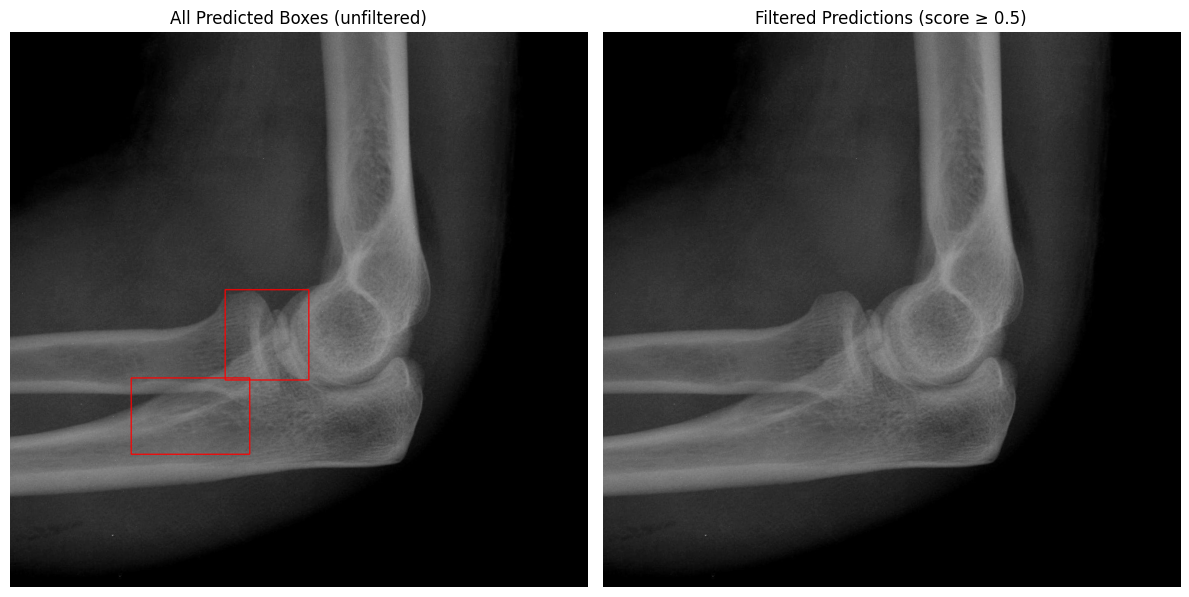

Predictions — total boxes: 2  above threshold: 0


In [ ]:
# Inference on one validation batch using the last fold's model 
fold_model.eval()  # Switch to eval mode (disables gradient tracking in BN/Dropout)

# Fetch a fresh validation batch
val_images, val_targets = next(iter(val_loader))
val_images_gpu = [img.to(device) for img in val_images]

with torch.no_grad():
    predictions = fold_model(val_images_gpu)  # Returns: list of {boxes, labels, scores}

# Convert first image tensor to displayable numpy array 
img_np = (val_images[0].permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)
img_all   = img_np.copy()
img_filt  = img_np.copy()

boxes  = predictions[0]["boxes"].cpu().numpy()
scores = predictions[0]["scores"].cpu().numpy()

# Draw ALL predicted boxes (unfiltered) in red
for box in boxes:
    x1,y1,x2,y2 = map(int, box)
    cv2.rectangle(img_all, (x1,y1),(x2,y2),(255,0,0),2)

# Draw FILTERED boxes (score > 0.5) in green
for box, score in zip(boxes, scores):
    if score >= 0.5:
        x1,y1,x2,y2 = map(int, box)
        cv2.rectangle(img_filt,(x1,y1),(x2,y2),(0,200,0),2)
        cv2.putText(img_filt, f"{score:.2f}", (x1, max(y1-5,0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4,(0,200,0),1)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_all)
axes[0].axis("off")
axes[0].set_title("All Predicted Boxes (unfiltered)")
axes[1].imshow(img_filt)
axes[1].axis("off")
axes[1].set_title("Filtered Predictions (score ≥ 0.5)")
plt.tight_layout()
plt.savefig("inference_result.png", dpi=120)
plt.show()

# Print scores for transparency
print(f"Predictions - total boxes: {len(boxes)}  above threshold: {(scores>=0.5).sum()}")

## Section 10 - Final Summary
A consolidated view of the full cross-fold training trajectory alongside the final Precision / Recall / F1 metrics for easy copy-paste into the report.


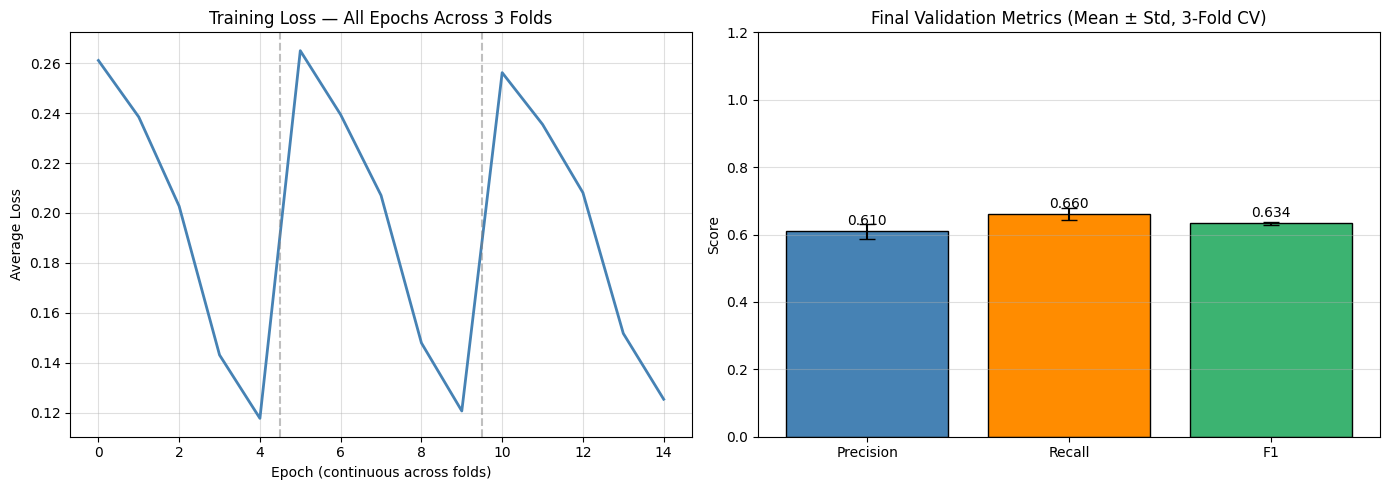


── Final Report Metrics ──
Precision : 0.6104 ± 0.0222
Recall    : 0.6601 ± 0.0174
F1 Score  : 0.6337 ± 0.0039
mAP@0.5   : 0.6294 ± 0.0037


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Flat loss history across all folds
axes[0].plot(loss_history, color='steelblue', linewidth=2)
# Mark fold boundaries with vertical lines
fold_boundary = NUM_EPOCHS
for fb in [fold_boundary, 2*fold_boundary]:
    axes[0].axvline(fb - 0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title("Training Loss - All Epochs Across 3 Folds")
axes[0].set_xlabel("Epoch (continuous across folds)")
axes[0].set_ylabel("Average Loss")
axes[0].grid(True, alpha=0.4)

# Right: Final metric summary bar chart 
metric_names = ['Precision', 'Recall', 'F1']
metric_means = [np.mean(fold_precisions), np.mean(fold_recalls), np.mean(fold_f1s)]
metric_stds = [np.std(fold_precisions),  np.std(fold_recalls),  np.std(fold_f1s)]

bars = axes[1].bar(metric_names, metric_means, yerr=metric_stds,
                   color=['steelblue','darkorange','mediumseagreen'],
                   capsize=6, edgecolor='black')
for bar, val in zip(bars, metric_means):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f"{val:.3f}", ha='center', va='bottom', fontsize=10)
axes[1].set_ylim(0, 1.2)
axes[1].set_title("Final Validation Metrics (Mean ± Std, 3-Fold CV)")
axes[1].set_ylabel("Score")
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig("final_summary.png", dpi=120)
plt.show()

print("\nFinal Report Metrics")
print(f"Precision : {np.mean(fold_precisions):.4f} ± {np.std(fold_precisions):.4f}")
print(f"Recall    : {np.mean(fold_recalls):.4f} ± {np.std(fold_recalls):.4f}")
print(f"F1 Score  : {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")
print(f"mAP@0.5   : {np.mean(fold_maps):.4f} ± {np.std(fold_maps):.4f}")